In [1]:
# Bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.models import Model

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()  # carrega o conjunto CIFAR-10

print("Imagens de treino:", x_train.shape)  # mostra o tamanho dos dados de treino
print("Imagens de teste:", x_test.shape)  # mostra o tamanho dos dados de teste

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1681s 10us/step
Imagens de treino: (50000, 32, 32, 3)
Imagens de teste: (10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0  # transforma os pixels para 0/1
x_test = x_test / 255.0  # aplica a mesma transformação nos dados de teste

y_train = y_train.flatten()  # transforma os rótulos em um vetor
y_test = y_test.flatten()  # transforma os rótulos de teste em um vetor

print("Menor valor:", x_train.min())  # mostra o menor valor dos pixels
print("Maior valor:", x_train.max())  # mostra o maior valor dos pixels

Menor valor: 0.0
Maior valor: 1.0


In [4]:
classes = [ # Do CIFAR-10
    'avião',
    'automóvel',
    'pássaro',
    'gato',
    'veado',
    'cachorro',
    'sapo',
    'cavalo',
    'navio',
    'caminhão'
]

print("Quantidade de classes:", len(classes))

Quantidade de classes: 10


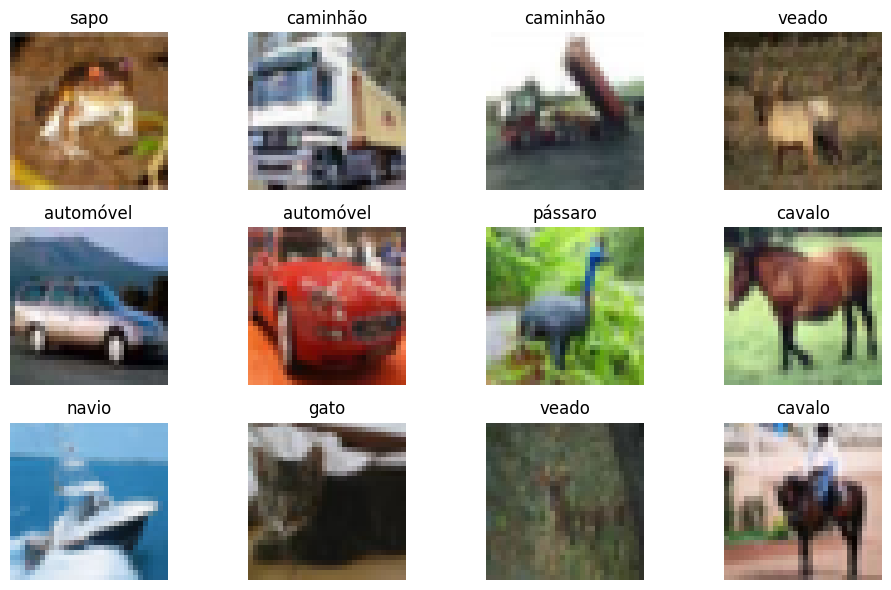

In [5]:
plt.figure(figsize=(10, 6))  # define o tamanho da figura

for i in range(12):
    plt.subplot(3, 4, i + 1)  # cria uma grade com 3 linhas e 4 colunas
    plt.imshow(x_train[i])  # mostra a imagem
    plt.title(classes[y_train[i]])  # mostra o nome da classe
    plt.axis('off')  # remove os eixos

plt.tight_layout()  # organiza os elementos
plt.show()  # exibe as imagens

In [6]:
i = Input(shape=(32, 32, 3))  # define imagens de 32x32 pixels com 3 canais RGB

In [8]:
# Primeira convolução
x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)  # extrai características das imagens
x = BatchNormalization()(x)  # normaliza as ativações da camada anterior
x = MaxPooling2D((2, 2))(x)  # reduz pela metade o tamanho espacial

# Segunda convolução
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)  # extrai características mais complexas
x = BatchNormalization()(x)  # normaliza os valores
x = MaxPooling2D((2, 2))(x)  # reduz novamente o tamanho

# Terceira convolução
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)  # aprende características mais complexas
x = BatchNormalization()(x)  # normaliza as ativações
x = MaxPooling2D((2, 2))(x)  # reduz novamente a dimensão

x = Flatten()(x)  # transforma os mapas de características em um vetor
x = Dense(128, activation='relu')(x)  # camada responsável por combinar as características
x = Dropout(0.3)(x)  # desativa aleatoriamente 30% dos neurônios durante o treinamento
x = Dense(10, activation='softmax')(x)  # retorna a probabilidade para cada uma das 10 classes

model = Model(i, x)  # cria a rede neural usando a entrada e a saída definidas

In [9]:
model.summary()  # mostra a arquitetura da rede

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Criando modelo

In [11]:
# Treinando modelo
historico = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15, batch_size=64)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 205ms/step - accuracy: 0.4842 - loss: 1.4593 - val_accuracy: 0.4507 - val_loss: 1.6266
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 204ms/step - accuracy: 0.6338 - loss: 1.0427 - val_accuracy: 0.6220 - val_loss: 1.1049
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 200s 202ms/step - accuracy: 0.6942 - loss: 0.8725 - val_accuracy: 0.6635 - val_loss: 0.9598
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 209s 210ms/step - accuracy: 0.7382 - loss: 0.7484 - val_accuracy: 0.7070 - val_loss: 0.9032
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 204ms/step - accuracy: 0.7655 - loss: 0.6636 - val_accuracy: 0.6318 - val_loss: 1.2077
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 162s 208ms/step - accuracy: 0.7857 - loss: 0.6055 - val_accuracy: 0.6917 - val_loss: 0.9253
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 209ms/step - accuracy: 0.8132 - loss: 0.5298 - val_accuracy: 0.7352 - val_loss: 0.7968
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 212ms/step - accuracy: 0.8344 -

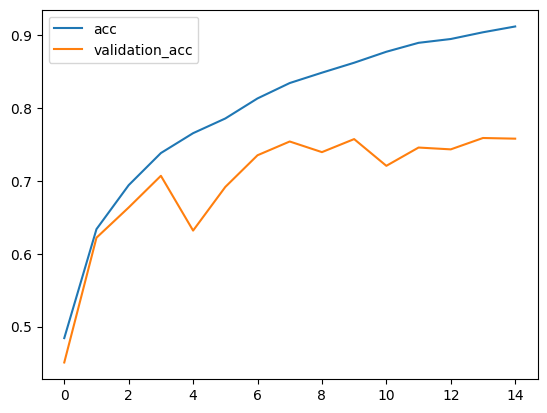

In [14]:
plt.plot(historico.history['accuracy'],label='acc')
plt.plot(historico.history['val_accuracy'],label='validation_acc')
#comparo a acuracia no treino e com dados que nunca viu
plt.legend()

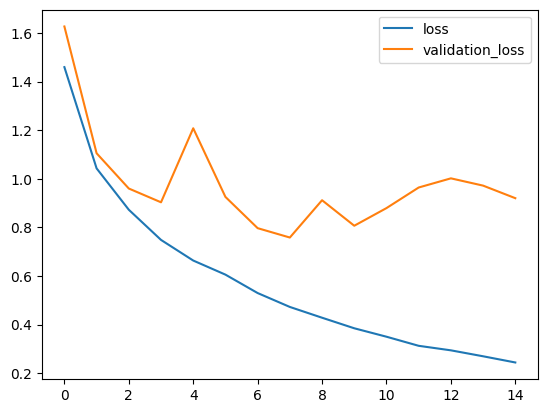

In [16]:
plt.plot(historico.history['loss'],label='loss')
plt.plot(historico.history['val_loss'],label='validation_loss')
#comparo o loss no treino e com dados que nunca viu
plt.legend()